# Load modules

In [31]:
import dask_jobqueue
import dask.distributed as dask_distributed
import dask
import os
import xarray as xr
import numpy as np
import pyproj
from gsw import f

import functions
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib.pyplot as plt

# Open dask-cluster

In [2]:
%%time
cluster = dask_jobqueue.SLURMCluster(cores=4,memory='20GB',processes=1,queue='base', walltime='24:00:00',interface='ib0',local_directory='$TMPDIR')
client = dask.distributed.Client(cluster)
cluster.scale(jobs=6)
client

CPU times: user 604 ms, sys: 783 ms, total: 1.39 s
Wall time: 7.9 s


/gxfs_home/geomar/smomw691/miniconda3/envs/py3_std/lib/python3.7/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35929 instead
  f"Port {expected} is already in use.\n"


Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://172.18.4.109:35929/status,
Dashboard: http://172.18.4.109:35929/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.18.4.109:38705,Workers: 0
Dashboard: http://172.18.4.109:35929/status,Total threads: 0
Started: Just now,Total memory: 0 B


# Define period and region of interest

In [3]:
lon_c=15.7
lat_c=-37.8
frq = '1d'  
yeara = 2013

pos_west,pos_east,pos_south,pos_north  = lon_c-2,lon_c+2,lat_c-2,lat_c+2

#eSQG parameters:
cc=2
N02=3.4e-6

# Define directories

In [4]:
hcs = 300 # horizontal chunk size
path_data = '/gxfs_work/geomar/smomw355/model_data/ocean-only/INALT60.L120-KRS0020/nemo/'
path_mask = path_data + 'suppl/2_INALT60.L120-KRS0020_mesh_mask.nc'
path_data += 'output/2_INALT60.L120-KRS0020_'

# Read data

In [7]:
ds_mask = xr.open_dataset(path_mask,chunks={'x':hcs,'y':hcs})
ds_mask_region = ds_mask.where((ds_mask.nav_lat>pos_south-1.2) & (ds_mask.nav_lat<pos_north+1.2) & (ds_mask.nav_lon>pos_west-1.2) & (ds_mask.nav_lon<pos_east+1.2), drop=True)

#SSH
paths = !ls {path_data + frq + '_' + str(yeara) + '*' + '_grid_T.nc'}
ds = xr.open_mfdataset(paths,chunks={'x':hcs,'y':hcs,'deptht':1,'time_counter':-1}).squeeze().rename({'deptht':'z'})
ds_ssh_region = ds.where((ds_mask.nav_lat>pos_south-1.2) & (ds_mask.nav_lat<pos_north+1.2) & (ds_mask.nav_lon>pos_west-1.2) & (ds_mask.nav_lon<pos_east+1.2), drop=True)

#Vertical velocity
paths = !ls {path_data + frq + '_' + str(yeara) + '*' + '_grid_W.nc'}
ds = xr.open_mfdataset(paths,chunks={'x':hcs,'y':hcs,'depthw':1,'time_counter':-1}).squeeze().rename({'depthw':'z'})
ds_w_region = ds.where((ds_mask.nav_lat>pos_south-1.2) & (ds_mask.nav_lat<pos_north+1.2) & (ds_mask.nav_lon>pos_west-1.2) & (ds_mask.nav_lon<pos_east+1.2), drop=True)

#Zonal velocity
paths = !ls {path_data + frq + '_' + str(yeara) + '*' + '_grid_U.nc'}
ds = xr.open_mfdataset(paths,chunks={'x':hcs,'y':hcs,'depthu':1,'time_counter':-1}).squeeze().rename({'depthu':'z'})
ds_u_region = ds.where((ds_mask.nav_lat>pos_south-1.2) & (ds_mask.nav_lat<pos_north+1.2) & (ds_mask.nav_lon>pos_west-1.2) & (ds_mask.nav_lon<pos_east+1.2), drop=True)

#Meridional velocity
paths = !ls {path_data + frq + '_' + str(yeara) + '*' + '_grid_V.nc'}
ds = xr.open_mfdataset(paths,chunks={'x':hcs,'y':hcs,'depthv':1,'time_counter':-1}).squeeze().rename({'depthv':'z'})
ds_v_region = ds.where((ds_mask.nav_lat>pos_south-1.2) & (ds_mask.nav_lat<pos_north+1.2) & (ds_mask.nav_lon>pos_west-1.2) & (ds_mask.nav_lon<pos_east+1.2), drop=True)

#Resize dataset to the first 1000 m
mask_1000 = ds_ssh_region.z <= 1000
ds_mask_region = ds_mask_region.where(mask_1000, drop=True)
ds_v_region=ds_v_region.where(mask_1000, drop=True)
ds_u_region=ds_u_region.where(mask_1000, drop=True)

mask_1000_w = ds_w_region.z <= 1050
ds_w_region = ds_w_region.where(mask_1000_w, drop=True)

/gxfs_home/geomar/smomw691/miniconda3/envs/py3_std/lib/python3.7/site-packages/xarray/core/indexing.py:1233: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  value = value[(slice(None),) * axis + (subkey,)]
/gxfs_home/geomar/smomw691/miniconda3/envs/py3_std/lib/python3.7/site-packages/xarray/core/indexing.py:1233: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': Tr

# Define a regular metric grid (needed for the eSQG comparison) for interpolation

In [10]:
dx=2
lon_grid=ds_w_region.nav_lon
lat_grid=ds_w_region.nav_lat

#Define the grid
a = pyproj.Transformer.from_crs(4326,3395).transform(lon_grid,lat_grid) # project WGS84 onto metric grid
y3 = a[0]
x3 = a[1]
x3min = np.nanmin(x3,1)
y3min = np.nanmin(y3,0)
Y3min,X3min = np.meshgrid(y3min, x3min)
x1=(x3-X3min)/1000
y1=(y3-Y3min)/1000
x_len = int(np.floor(np.amax(x1))+1)
y_len = int(np.floor(np.amax(y1))+1)
x_dim = np.linspace(0, x_len, int(x_len/dx), endpoint=False)
y_dim = np.linspace(0, y_len, int(y_len/dx), endpoint=False)
x2, y2 = np.meshgrid(x_dim, y_dim)

#Add nav_lon and nav_lat back from the interpolation 
x2_proj = x2*1000 + x3min[0]
y2_proj = y2*1000 + y3min[0]
transformer_back = pyproj.Transformer.from_crs(3395, 4326, always_xy=True)
lat2, lon2 = transformer_back.transform(y2_proj,x2_proj)

#Make square - for SQG
size_x=len(lon2[0,:])
size_y=len(lon2[:,0])

if size_y>size_x:
    delta_points=size_y-size_x
    lon2 = lon2[:size_x,:]
    lat2 = lat2[:size_x,:]
else:
    delta_points=size_x-size_y
    lon2 = lon2[:,:size_y]
    lat2 = lat2[:,:size_y]

lon2 = lon2[50:-50,50:-50]
lat2 = lat2[50:-50,50:-50]

# Loop over each month of one year and compute daily spectral and spatial correlation

In [ ]:
lfilter=40
month_array=np.arange(1,13)
find_k=0

path_current = os.getcwd()
path_save_spectral = os.path.join(path_current, 'Spectral_correlation') 
os.makedirs(path_save_spectral, exist_ok=True)
os.makedirs(os.path.join(path_save_spectral, 'w'), exist_ok=True)
os.makedirs(os.path.join(path_save_spectral, 'vorticity'), exist_ok=True)

path_save_spatial = os.path.join(path_current, 'Spatial_correlation') 
os.makedirs(path_save_spectral, exist_ok=True)
os.makedirs(os.path.join(path_save_spatial, 'w'), exist_ok=True)
os.makedirs(os.path.join(path_save_spatial, 'vorticity'), exist_ok=True)

for m in month_array:
    ds_w_region_m = ds_w_region.where(ds_w_region.time_counter.dt.month.isin([m]), drop=True)
    ds_ssh_region_m = ds_ssh_region.where(ds_ssh_region.time_counter.dt.month.isin([m]), drop=True)
    ds_u_region_m = ds_u_region.where(ds_u_region.time_counter.dt.month.isin([m]), drop=True)
    ds_v_region_m = ds_v_region.where(ds_v_region.time_counter.dt.month.isin([m]), drop=True)

    ssh_model = ds_ssh_region_m.sossheig.where(ds_mask_region.tmask.isel(z=0)==1).squeeze()    
    u_model = ds_u_region_m.vozocrtx.where(ds_mask_region.umask==1).squeeze()    
    v_model = ds_v_region_m.vomecrty.where(ds_mask_region.umask==1).squeeze() 
    w_org = ds_w_region_m.vovecrtz  

    #Interpolate w on the vertical at SSH grid points since the eSQG will produce w estimates at SSH grid points
    z1=ds_w_region_m.z
    z2=ds_ssh_region_m.z.where(mask_1000, drop=True).rename({"z": "z_new"})
    
    w_gridded_vert = xr.apply_ufunc(interp_to_prof,
                         w_org.chunk(
            {"x": 100, "y": 100, "z":-1,'time_counter':7}), z1, z2,
                         input_core_dims=[["z"], ["z"], ["z_new"]],
                         output_core_dims=[["z_new"]],
                         exclude_dims=set(("z")),
                         vectorize = True,
                         dask="parallelized",
                         output_dtypes=[w_org.dtype]).rename({"z_new": "z"})
    #Mask data
    w_gridded_vert=w_gridded_vert.where(ds_mask_region.tmask==1).squeeze()*60*60*24

    #Interpolate the fields on the horizontal on the regular 2-km grid
    w_gridded = xr.apply_ufunc(interp_to_grid,
                         w_gridded_vert.chunk(
            {"x": -1, "y": -1, "z":10,'time_counter':7}), x1, y1, x2, y2,
                         input_core_dims=[["y","x"], ["y","x"], ["y","x"], ["new_y","new_x"], ["new_y","new_x"]],
                         output_core_dims=[["new_y","new_x"]],
                         exclude_dims=set(("y","x")),
                         vectorize = True,
                         dask="parallelized",
                         output_dtypes=[w_gridded_vert.dtype]).rename({"new_y": "y", "new_x": "x"})
    
    ssh_gridded = xr.apply_ufunc(interp_to_grid,
                 ssh_model.chunk(
    {"x": -1, "y": -1,'time_counter':7}), x1, y1, x2, y2,
                 input_core_dims=[["y","x"], ["y","x"], ["y","x"], ["new_y","new_x"], ["new_y","new_x"]],
                 output_core_dims=[["new_y","new_x"]],
                 exclude_dims=set(("y","x")),
                 vectorize = True,
                 dask="parallelized",
                 output_dtypes=[ssh_model.dtype]).rename({"new_y": "y", "new_x": "x"})
        
    u_gridded = xr.apply_ufunc(interp_to_grid,
                 u_model.chunk(
    {"x": -1, "y": -1, "z":10, 'time_counter':7}), x1, y1, x2, y2,
                 input_core_dims=[["y","x"], ["y","x"], ["y","x"], ["new_y","new_x"], ["new_y","new_x"]],
                 output_core_dims=[["new_y","new_x"]],
                 exclude_dims=set(("y","x")),
                 vectorize = True,
                 dask="parallelized",
                 output_dtypes=[u_model.dtype]).rename({"new_y": "y", "new_x": "x"})
    
    v_gridded = xr.apply_ufunc(interp_to_grid,
                 v_model.chunk(
    {"x": -1, "y": -1, "z":10,'time_counter':7}), x1, y1, x2, y2,
                 input_core_dims=[["y","x"], ["y","x"], ["y","x"], ["new_y","new_x"], ["new_y","new_x"]],
                 output_core_dims=[["new_y","new_x"]],
                 exclude_dims=set(("y","x")),
                 vectorize = True,
                 dask="parallelized",
                 output_dtypes=[v_model.dtype]).rename({"new_y": "y", "new_x": "x"})

    #Filter w at 40 km
    w_filtered = filtering_lanczos(w_gridded, lfilter).isel(x=slice(50,-50),y=slice(50,-50)).compute()
    ssh_filtered = filtering_lanczos(ssh_gridded, lfilter).compute()
    u_filtered = filtering_lanczos(u_gridded, lfilter)
    v_filtered = filtering_lanczos(v_gridded, lfilter)
    
    w_model= xr.Dataset(
                data_vars=dict(
                w_model=(["time_counter", "z","y", "x"], w_filtered.data)
                ),
                coords=dict(
                    time_counter=("time_counter", w_filtered.time_counter.values),
                    x=("x", w_filtered.x.values),
                    y=("y", w_filtered.y.values),
                    z=(["z"], w_filtered.z.values)
                    ) 
                )

    #Compute vorticity from u and v
    f0=abs(np.mean(f(lat2)))
    dudy = (u_filtered.shift(y=-1) - u_filtered.shift(y=1)) / (2*1000*dx)
    dvdx = (v_filtered.shift(x=-1) - v_filtered.shift(x=1)) / (2*1000*dx) 
    
    zeta_model=dvdx-dudy
    zeta_model = zeta_model.isel(x=slice(50,-50),y=slice(50,-50)).compute()/f0
    
    zeta_model= xr.Dataset(
                data_vars=dict(
                zeta_model=(["time_counter", "z","y", "x"], zeta_model.data)
                ),
                coords=dict(
                    time_counter=("time_counter", w_filtered.time_counter.values),
                    x=("x", w_filtered.x.values),
                    y=("y", w_filtered.y.values),
                    z=(["z"], w_filtered.z.values)
                    ) 
                )
    #eSQG
    vorticity_SQG = xr.apply_ufunc(compute_SQG_zeta,
                         ssh_filtered.chunk(
            {"x": -1, "y": -1, "time_counter":7}), N02, f0, -zeta_model.z.data, dx,
                         input_core_dims=[["y","x"], [], [],["z"]],
                         output_core_dims=[["z","y","x"]],
                         vectorize = True,
                         dask="parallelized",
                         output_dtypes=[ssh_filtered.dtype]
                         )
    
    vorticity_SQG= xr.Dataset(
                data_vars=dict(
                zeta_SQG=(["time_counter", "z","y", "x"], -vorticity_SQG.isel(x=slice(50,-50),y=slice(50,-50)).data/f0)
                ),
                coords=dict(
                    time_counter=("time_counter", w_filtered.time_counter.values),
                    x=("x", w_filtered.x.values),
                    y=("y", w_filtered.y.values),
                    z=(["z"], w_filtered.z.values)
                    ) 
                )

    w_sqg = xr.apply_ufunc(compute_SQG_w,
                         ssh_filtered.chunk(
            {"x": -1, "y": -1, "time_counter":7}), N02, cc, f0, -zeta_model.z.data, dx,
                         input_core_dims=[["y","x"], [], [], [],["z"]],
                         output_core_dims=[["z","y","x"]],
                         vectorize = True,
                         dask="parallelized",
                         output_dtypes=[ssh_filtered.dtype]
                         )
    
    w_sqg= xr.Dataset(
                data_vars=dict(
                w_SQG=(["time_counter", "z","y", "x"], w_sqg.isel(x=slice(50,-50),y=slice(50,-50)).data)
                ),
                coords=dict(
                    time_counter=("time_counter", w_filtered.time_counter.values),
                    x=("x", w_filtered.x.values),
                    y=("y", w_filtered.y.values),
                    z=(["z"], w_filtered.z.values)
                    ) 
                )

    if find_k==0:
        kiso, Ei=compute_coherence(vorticity_SQG.zeta_SQG.isel(time_counter=0,z=0).values,zeta_model.zeta_model.isel(time_counter=0,z=0).values,dx)
        find_k=1
        
    coherence_vorticity = xr.apply_ufunc(compute_coherence,vorticity_SQG.zeta_SQG, zeta_model.zeta_model
                         , dx,
                         input_core_dims=[["y", "x"], ["y", "x"],[]],
                         output_core_dims=[["k"], ["k"]],
                         output_dtypes = ('float64','float64'),
                         dask_gufunc_kwargs={'output_sizes': {'k': len(kiso)}},
                         vectorize=True,  # loop over non-core dims
                         dask="parallelized",
    
        )
    
    coherence_vorticity_dataset= xr.Dataset(
        data_vars=dict(
        spectra=(["time_counter", "z","k"], coherence_vorticity[1].data)
        ),
        coords=dict(
            time_counter=("time_counter", w_filtered.time_counter.values),
            z=(["z"], w_filtered.z.values),
            k=(["k"], coherence_vorticity[0].isel(z=0,time_counter=0).data) 
        ))

    coherence_vorticity_dataset.to_netcdf(path=path_save_spectral+'vorticity/'+str(yeara)+'_'+str(m)+'.nc')

    coherence_w = xr.apply_ufunc(compute_coherence,w_sqg.w_SQG, w_model.w_model
         , dx,
         input_core_dims=[["y", "x"], ["y", "x"],[]],
         output_core_dims=[["k"], ["k"]],
         output_dtypes = ('float64','float64'),
         dask_gufunc_kwargs={'output_sizes': {'k': len(kiso)}},
         vectorize=True,  # loop over non-core dims
         dask="parallelized"
    
        )
    
    coherence_w_dataset= xr.Dataset(
        data_vars=dict(
        spectra=(["time_counter", "z","k"], coherence_w[1].data)
        ),
        coords=dict(
            time_counter=("time_counter", w_filtered.time_counter.values),
            z=(["z"], w_filtered.z.values),
            k=(["k"], coherence_w[0].isel(z=0,time_counter=0).data) 
        ))

    coherence_w_dataset.to_netcdf(path=path_save_spectral+'w/'+str(yeara)+'_'+str(m)+'.nc')

    corr_vorticity=xr.apply_ufunc(compute_correlation,
             vorticity_SQG.zeta_SQG, zeta_model.zeta_model,
             input_core_dims=[["y","x"], ["y","x"]],
             output_core_dims=[[]],
             vectorize = True,
             dask="parallelized",
             output_dtypes=[ssh_filtered.dtype]
             ).compute()

    corr_w=xr.apply_ufunc(compute_correlation,
                     w_sqg.w_SQG, w_model.w_model,
                     input_core_dims=[["y","x"], ["y","x"]],
                     output_core_dims=[[]],
                     vectorize = True,
                     dask="parallelized",
                     output_dtypes=[ssh_filtered.dtype]
                     ).compute()

    corr_vorticity.to_netcdf(path=path_save_spatial+'vorticity/'+str(yeara)+'_'+str(m)+'.nc')
    corr_w.to_netcdf(path=path_save_spatial+'w/'+str(yeara)+'_'+str(m)+'.nc')
    print('File saved')

/gxfs_home/geomar/smomw691/miniconda3/envs/py3_std/lib/python3.7/site-packages/xarray/core/indexing.py:1233: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  value = value[(slice(None),) * axis + (subkey,)]
/gxfs_home/geomar/smomw691/miniconda3/envs/py3_std/lib/python3.7/site-packages/xarray/core/indexing.py:1233: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': Tr

zeta_model:
(30, 62, 255, 255)


# Plot figure spatial and spectral correlation 

## Read data

In [ ]:
paths = !ls {path_save_spatial+'/vorticity/' + '2013*' + '.nc'}
ds_corr_vorticity = xr.open_mfdataset(paths)

paths = !ls {path_save_spatial+'/w/' + '2013*' + '.nc'}
ds_corr_w = xr.open_mfdataset(paths)

paths = !ls {path_save_spectral+'/vorticity/' + '2013*' + '.nc'}
ds_spectra_vorticity = xr.open_mfdataset(paths)

paths = !ls {path_save_spectral+'/w/' + '2013*' + '.nc'}
ds_spectra_w = xr.open_mfdataset(paths)

## Find mean MLD time series

In [29]:
mld_timeseries = ds_ssh_region.sobowlin

# Find MLD mean
MLD_gridded = xr.apply_ufunc(interp_to_grid,
    mld_timeseries.chunk(dict(y=-1, x=-1, time_counter=90)), x1, y1, x2, y2,
    input_core_dims=[["y","x"], ["y","x"], ["y","x"], ["new_y","new_x"], ["new_y","new_x"]],
    output_core_dims=[["new_y","new_x"]],
    exclude_dims=set(("y","x")),
    vectorize = True,
    dask="parallelized",
    output_dtypes=[mld_timeseries.dtype]).rename({"new_y": "y", "new_x": "x"})

#Resize datasets to be square (for SQG)
size_x=len(MLD_gridded.x)
size_y=len(MLD_gridded.y)
if size_y>size_x:
    MLD_final = MLD_gridded.isel(y=slice(0,size_x))
else:
    MLD_final = MLD_gridded.isel(x=slice(0,size_y))
MLD_final = MLD_final.isel(x=slice(50,-50),y=slice(50,-50))

MLD_mean=MLD_final.mean(dim=['x','y']).compute()

/gxfs_home/geomar/smomw691/miniconda3/envs/py3_std/lib/python3.7/site-packages/ipykernel_launcher.py:95: UserWarning: FixedFormatter should only be used together with FixedLocator


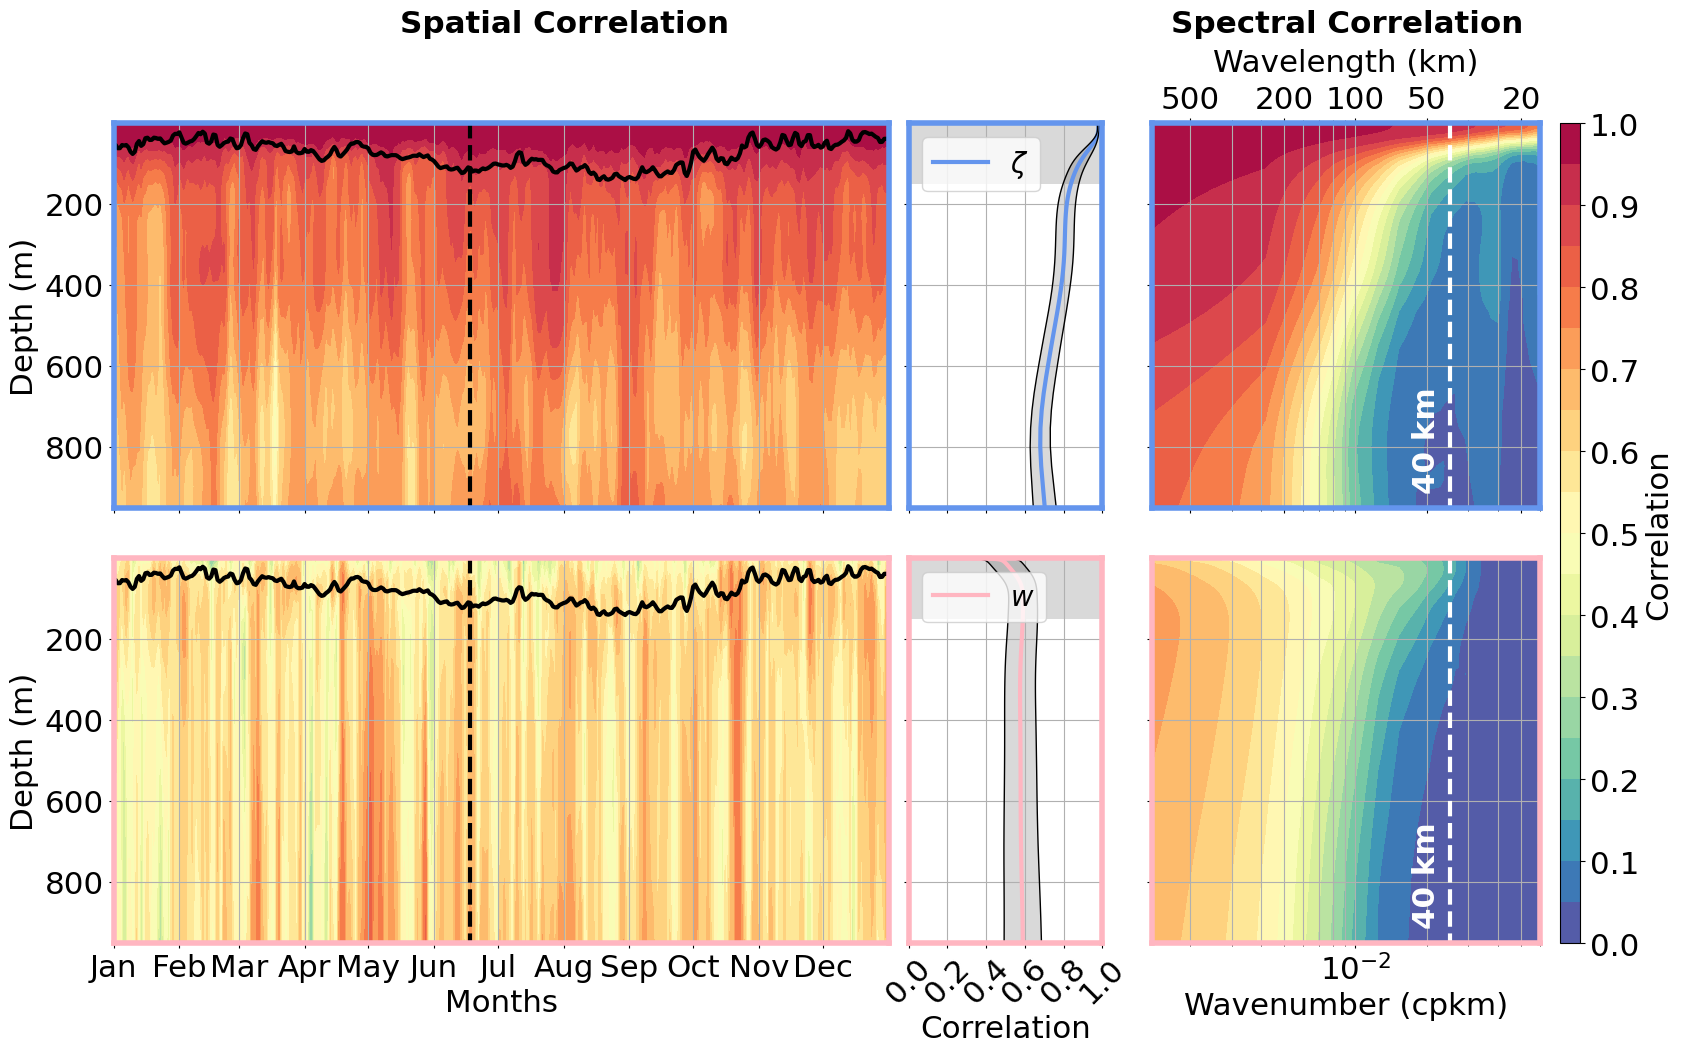

In [32]:
path_save_fig = os.path.join(path_current, 'Figure_manuscript') 
os.makedirs(path_save_fig, exist_ok=True)

#Plot parameters
color_list = ['lightpink','yellowgreen', 'cornflowerblue', 'orange']
ft=22.3
month_label=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

#Start figure
fig = plt.figure(figsize=(10,5))
    #Vorticity
data = ds_corr_vorticity
data2 = ds_spectra_vorticity
mean_profile = data.__xarray_dataarray_variable__.mean(dim='time_counter').compute()
env_5 = mean_profile-data.__xarray_dataarray_variable__.std(dim=['time_counter']).compute()
env_95 = mean_profile+data.__xarray_dataarray_variable__.std(dim=['time_counter']).compute()

spectra = data2.spectra.mean(dim='time_counter').compute()
month_number = data.time_counter.dt.month
_, ticks_months = np.unique(month_number, return_index=True)
ymin, ymax = data.z.isel(z=0), data.z.isel(z=-1)
        #Spatial correlation
im = plt.contourf(np.arange(len(data.time_counter)), data.z, data.__xarray_dataarray_variable__.T, cmap='Spectral_r', vmin=0, vmax=1, levels=np.arange(0,1.02,0.05))
ax1=plt.gca()
ax1.set_ylim(ymin, ymax) 
ax1.set_xlim(0, len(data.time_counter)) 
ax1.invert_yaxis()
ax1.set_ylabel('Depth (m)', fontsize=ft)
plt.grid()
ax1.set_xticks(ticks_months)
ax1.set_xticklabels([])
ax1.tick_params(axis='both',labelsize=ft)
ax1.text(135, -225, 'Spatial Correlation', color='k', fontweight='semibold',fontsize=ft)

for axis in ['top','bottom','left','right']:
    ax1.spines[axis].set_linewidth(4)
    ax1.spines[axis].set_color('cornflowerblue')

            #Add MLD
ax1.plot(np.arange(len(data.time_counter)), MLD_mean, 'k', linewidth=3)
pos1=ax1.get_position()
ax1.plot([168, 168], [ymin, ymax], 'k--', linewidth=3)

        #Add mean profile spatial correlation
ax2 = fig.add_axes([pos1.x0+pos1.width+0.02, pos1.y0, pos1.width/4,pos1.height])

ax2.plot(mean_profile, data.z, 'cornflowerblue', linewidth=3, label='$\zeta$')
ax2.legend(fontsize=ft-2.5,loc='upper left')
ax2.plot(env_5, data.z, 'k', linewidth=1)
ax2.plot(env_95, data.z, 'k', linewidth=1)

            #Fill in grey between envelop
x = np.concatenate((env_5, np.flip(env_95), [env_5[0]]))
y = np.concatenate((data.z, np.flip(data.z), [data.z.isel(z=0)]))
ax2.fill(x,y,'k', alpha=.15)
ax2.set_xticks(np.arange(0,1.05,.2))
ax2.set_yticklabels([])
ax2.set_xticklabels([])
ax2.tick_params(axis='both',labelsize=ft)
for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(4)
    ax2.spines[axis].set_color('cornflowerblue')
    
ax2.set_ylim(ymin, ymax) 
ax2.set_xlim(0, 1) 
ax2.invert_yaxis()

            #Add MLD mask
x = np.concatenate((env_5, np.flip(env_95), [env_5[0]]))
y = np.concatenate((data.z, np.flip(data.z), [data.z.isel(z=0)]))
ax2.fill([0,1,1,0,0],[150, 150, 0, 0, 150],'k', alpha=.15)
plt.grid()

        #Spectral correlation
pos2=ax2.get_position()
ax3 = fig.add_axes([pos2.x0+pos2.width+0.05, pos2.y0, 2*pos2.width,pos1.height])
xmin, xmax = data2.k.min(), 6e-2
im = ax3.contourf(data2.k,data2.z, spectra,cmap='Spectral_r', vmin=0, vmax=1, levels=np.arange(0,1.02,0.05))
ax3.plot([1/40,1/40], [0,1000], 'w--', linewidth=3)
ax3.set_yticklabels([])
ax3.set_ylim(ymin, ymax) 
ax3.set_xlim(xmin, xmax) 
ax3.set_xscale('log')
ax3.invert_yaxis()
ax3.set_xticklabels([])
ax3.tick_params(axis='both',labelsize=ft)
ax3.text(1/600, -225, 'Spectral Correlation', color='k', fontweight='semibold',fontsize=ft)
plt.grid(True, which="both")
ax3.tick_params(bottom=True, top=True, left=True, right=False)

lambdadisp = np.array([20, 50, 100, 200, 500])
kdisp = 1 / lambdadisp
x_formatter = FixedFormatter(['20', '50', '100', '200', '500'])
x_locator = FixedLocator(kdisp)
ax3.xaxis.set_major_formatter(x_formatter)
ax3.xaxis.set_major_locator(x_locator)
ax3.tick_params(axis='x', which='both', top=True, labeltop=True) 
ax3.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
ax3.set_xlabel('Wavelength (km)', fontsize=ft, labelpad=10)
ax3.xaxis.set_label_position('top') 
ax3.text(1/58, 900, '40 km', color='w', fontweight='semibold', rotation=90,fontsize=ft)

for axis in ['top','bottom','left','right']:
    ax3.spines[axis].set_linewidth(4)
    ax3.spines[axis].set_color('cornflowerblue')
    
    #Vertical velocity
ax4 = fig.add_axes([pos1.x0, pos1.y0-pos1.height-.1, pos1.width,pos1.height])

data = ds_corr_w
data2 = ds_spectra_w
mean_profile = data.__xarray_dataarray_variable__.mean(dim='time_counter').compute()
env_5 = mean_profile-data.__xarray_dataarray_variable__.std(dim=['time_counter']).compute()
env_95 = mean_profile+data.__xarray_dataarray_variable__.std(dim=['time_counter']).compute()
spectra = data2.spectra.mean(dim='time_counter').compute()
        #Spatial correlation
ax4.contourf(np.arange(len(data.time_counter)), data.z, data.__xarray_dataarray_variable__.T, cmap='Spectral_r', vmin=0, vmax=1, levels=np.arange(0,1.02,0.05))
ax4.set_ylim(ymin, ymax) 
ax4.set_xlim(0, len(data.time_counter)) 
ax4.invert_yaxis()
ax4.set_xlabel('Months', fontsize=ft)
ax4.set_ylabel('Depth (m)', fontsize=ft)
ax4.tick_params(axis='both',labelsize=ft)
plt.grid()
ax4.set_xticks(ticks_months, labels=month_label)

            #Add MLD
ax4.plot(np.arange(len(data.time_counter)), MLD_mean, 'k', linewidth=3)
for axis in ['top','bottom','left','right']:
    ax4.spines[axis].set_linewidth(4)
    ax4.spines[axis].set_color('lightpink')
ax4.plot([168, 168], [ymin, ymax], 'k--', linewidth=3)
 
        #Add mean profile spatial correlation
ax5 = fig.add_axes([pos2.x0, pos2.y0-pos2.height-.1, pos2.width,pos2.height])
ax5.plot(mean_profile, data.z, 'lightpink', linewidth=3, label='$w$')
ax5.legend(fontsize=ft-2.5, loc='upper left')
ax5.plot(env_5, data.z, 'k', linewidth=1)
ax5.plot(env_95, data.z, 'k', linewidth=1)

            #Fill in grey between envelop
x = np.concatenate((env_5, np.flip(env_95), [env_5[0]]))
y = np.concatenate((data.z, np.flip(data.z), [data.z.isel(z=0)]))
ax5.fill(x,y,'k', alpha=.15)
ax5.set_yticklabels([])
ax5.tick_params(axis='both',labelsize=ft)
ax5.set_xticks(np.arange(0,1.05,.2))
plt.xticks(rotation=45)

ax5.set_ylim(ymin, ymax) 
ax5.set_xlim(0, 1) 
ax5.invert_yaxis()
ax5.set_xlabel('Correlation', fontsize=ft)
plt.grid()

for axis in ['top','bottom','left','right']:
    ax5.spines[axis].set_linewidth(4)
    ax5.spines[axis].set_color('lightpink')

            #Add MLD mask
x = np.concatenate((env_5, np.flip(env_95), [env_5[0]]))
y = np.concatenate((data.z, np.flip(data.z), [data.z.isel(z=0)]))
ax5.fill([0,1,1,0,0],[150, 150, 0, 0, 150],'k', alpha=.15)

pos3 = ax3.get_position()
ax6 = fig.add_axes([pos3.x0, pos3.y0-pos3.height-.1, pos3.width,pos3.height])

        #Spectral correlation
xmin, xmax = data2.k.min(), 6e-2
im = ax6.contourf(data2.k,data2.z, spectra,cmap='Spectral_r', vmin=0, vmax=1, levels=np.arange(0,1.02,0.05))
ax6.plot([1/40,1/40], [0,1000], 'w--', linewidth=3)
ax6.set_yticklabels([])
ax6.set_ylim(ymin, ymax) 
ax6.set_xlim(xmin, xmax) 
ax6.set_xscale('log')
ax6.invert_yaxis()
ax6.tick_params(axis='both',labelsize=ft)
ax6.text(1/58, 900, '40 km', color='w', fontweight='semibold', rotation=90,fontsize=ft)

ax6.set_xlabel('Wavenumber (cpkm)', fontsize=ft)
plt.grid(True, which="both")

for axis in ['top','bottom','left','right']:
    ax6.spines[axis].set_linewidth(4)
    ax6.spines[axis].set_color('lightpink')

#Add colorbar
pos6=ax6.get_position()

cax=fig.add_axes([pos6.x0+pos6.width+.02, pos6.y0, 0.02,pos6.height*2+.1])
cbar = fig.colorbar(im,cax=cax, orientation='vertical', ticks=np.arange(0,1.05,.1))
cbar.set_label('Correlation', fontsize=ft)
#cbar.ax.xaxis.set_ticks_position('top')
#cax.xaxis.set_label_position('top') 
cbar.ax.tick_params(labelsize=ft)

fig.savefig(path_save_fig + 'Figure_2.png',bbox_inches='tight',dpi=300)